In [20]:
import numpy as np
import sys, os
from pathlib import Path
# Add src directory to path for zarr_tools import
# sys.path.append(str(Path(__file__).parent.parent / 'src'))
# from zarr_tools import setup_dask_client
import yaml
import xarray as xr
import pandas as pd
import time
import psutil
import argparse
import cftime
import intake
import gc
import logging
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import colormaps as cmaps

In [2]:
def load_config(config_file, catalog_source):
    """
    Load configuration from YAML file for a specific catalog source.
    
    Args:
        config_file: str
            Path to the YAML configuration file
        catalog_source: str
            The catalog source key to load configuration for
            
    Returns:
        dict: Configuration dictionary for the specified source
    """
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    
    if catalog_source not in config:
        raise ValueError(f"Catalog source '{catalog_source}' not found in config file. "
                        f"Available sources: {list(config.keys())}")
    
    return config[catalog_source]

In [ ]:
def calc_precip_percentiles(pr, percentiles=[90, 95], time_duration='6h', method='linear'):
    """
    Calculate precipitation percentiles at specified time scales.
    
    Args:
        pr: xr.DataArray
            Precipitation data array with dimensions (time, cell) in mm/h
        percentiles: list of float
            Percentiles to compute (e.g., [90, 95] for 90th and 95th percentiles)
        time_duration: str
            Time duration for resampling. Options include:
            - '6h' or '6H': 6-hourly (no resampling if already 6-hourly)
            - '1D' or '24h': daily
            - '12h' or '12H': 12-hourly
            Default is '6h' (keeps original 6-hourly resolution)
        method: str
            Interpolation method for quantile calculation. Options include:
            - 'linear': linear interpolation (default)
            - 'lower': lower value
            - 'higher': higher value
            - 'midpoint': midpoint of two nearest values
            - 'nearest': nearest value
            
    Returns:
        dict: Dictionary with percentile values as keys and DataArrays as values
              e.g., {90: pr_p90, 95: pr_p95}
    """
    # Resample to specified time duration if needed
    if time_duration.lower() not in ['6h', '6hr']:
        # Convert time duration to pandas-compatible frequency string
        freq = time_duration.upper().replace('HR', 'H')
        print(f"Resampling precipitation from 6-hourly to {freq}...")
        # Resample by taking mean precipitation rate
        pr_resampled = pr.resample(time=freq).mean(keep_attrs=True)
    else:
        print(f"Using original 6-hourly precipitation data...")
        pr_resampled = pr
    
    # Calculate percentiles
    results = {}
    for p in percentiles:
        print(f"Computing {p}th percentile...")
        quantile_value = p / 100.0
        pr_percentile = pr_resampled.quantile(quantile_value, dim='time', method=method)
        pr_percentile.name = f'pr_p{p}'
        pr_percentile.attrs['long_name'] = f'{p}th percentile precipitation'
        pr_percentile.attrs['units'] = 'mm/h'
        pr_percentile.attrs['time_duration'] = time_duration
        results[p] = pr_percentile
    
    return results

In [3]:
# Get the command-line arguments
# args_dict = parse_cmd_args()
config_file = "/global/homes/f/feng045/program/waccem/gsrm_cooccurrencefeature/config/config_sources.yaml"
catalog_source = "scream_ne120"
# zoom = args_dict.get('zoom')
# n_workers = args_dict.get('n_workers')
# threads_per_worker = args_dict.get('threads_per_worker')
# chunk_days = args_dict.get('chunk_days')
# pcp_thresh = args_dict.get('pcp_thresh')

# chunk_days = 6
# pcp_thresh = 0.1  # mm/h

# Configuration parameters
zoom = 8
version = 'v1'
parallel = True

# Load configuration for the specified source
config = load_config(config_file, catalog_source)

# Extract configuration variables
source_name = config.get('source_name')
catalog_location = config.get('catalog_location', 'NERSC')
catalog_params = config.get('catalog_params', {}).copy()
varname_precip_liq = config.get('varname_precip_liq')
varname_precip_ice = config.get('varname_precip_ice')
pr_convert_factor = config.get('pr_convert_factor')
start_datetime = config.get('start_datetime')
end_datetime = config.get('end_datetime')

# Catalog parameters
catalog_file = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"

# # Input combined mask file
# in_dir = "/pscratch/sd/w/wcmca1/hackathon/cof_masks/"
# in_basename = f"{source_name}_cofmasks_hp{zoom}_{version}.zarr"
# in_zarr = f"{in_dir}{in_basename}"

In [9]:
# Load the mask dataset
# ds = xr.open_zarr(in_zarr, consolidated=True)
# ds = ds.pipe(egh.attach_coords)

# Special treatment for certain datasets not in the catalog
if catalog_source == "IR_IMERG":
    # Special case for IMERG data (not in catalog yet)
    dir_healpix = "/pscratch/sd/w/wcmca1/GPM/healpix/"
    in_basename = f"IMERG_V7_"
    time_res = "6H"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_zoom{zoom}_20190101_20211231.zarr"
    # Read IMERG dataset
    print(f"Loading IMERG dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "scream_ne120":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/scream/"
    in_basename = f"scream_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read SCREAM dataset
    print(f"Loading SCREAM dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "nicam_gl11":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/nicam_gl11/shifted/"
    in_basename = f"NICAM_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read NICAM dataset
    print(f"Loading NICAM dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "um_glm_n2560_RAL3p3":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/um_glm_n2560_RAL3p3/"
    in_basename = f"um_glm_n2560_RAL3p3_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read UM dataset
    print(f"Loading UM dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "casesm2_10km_nocumulus":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/casesm2_10km_nocumulus/"
    in_basename = f"casesm2_10km_nocumulus_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read CASESM2 dataset
    print(f"Loading CASESM2 dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

else:
    # Load the HEALPix catalog
    print(f"Loading HEALPix catalog: {catalog_file}")
    in_catalog = intake.open_catalog(catalog_file)
    if catalog_location:
        in_catalog = in_catalog[catalog_location]
    
    # Get the DataSet from the catalog
    ds_p = in_catalog[catalog_source](**catalog_params).to_dask()
    # Add lat/lon coordinates to the HEALPix DataSet
    ds_p = ds_p.pipe(egh.attach_coords)

# Check liquid precipitaiton variable
if varname_precip_liq in list(ds_p.keys()):
    # Convert liquid precipitation to mm/h
    pr = ds_p[varname_precip_liq] * pr_convert_factor
# Check if the ice precipitation variable exist in the dataset
if varname_precip_ice in list(ds_p.keys()):
    # Convert ice precipitation to liquid equivalent
    prs = ds_p[varname_precip_ice] * pr_convert_factor
    # Add ice precipitation to get total precipitation
    pr = pr + prs

Loading SCREAM dataset (NOT from catalog): /pscratch/sd/w/wcmca1/hackathon/healpix/scream/scream_pr6h_z8.zarr


In [5]:
ds_p

<xarray.Dataset> Size: 10GB
Dimensions:  (cell: 786432, time: 1589)
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
  * time     (time) datetime64[ns] 13kB 2019-08-01 ... 2020-09-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
Data variables:
    pr       (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
    rlut     (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          3
    averaging_frequency_units:    nhours
    averaging_type:               AVERAGE
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [10]:
pr

<xarray.DataArray 'pr' (time: 1589, cell: 786432)> Size: 5GB
dask.array<mul, shape=(1589, 786432), dtype=float32, chunksize=(28, 786432), chunktype=numpy.ndarray>
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
  * time     (time) datetime64[ns] 13kB 2019-08-01 ... 2020-09-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431

In [ ]:
pr_p90 = pr.quantile(0.90, dim='time').compute()
pr_p90

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


<xarray.DataArray 'pr' (cell: 786432)> Size: 6MB
array([0.40066108, 0.37431934, 0.40418437, ..., 0.17483422, 0.19912373,
       0.17396768])
Coordinates:
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    quantile  float64 8B 0.9

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Calculate Precipitation Percentiles

Test the new function with different time scales and percentiles

In [24]:
# Example 1: 6-hourly 90th and 95th percentiles
print("=" * 60)
print("Example 1: 6-hourly precipitation percentiles")
print("=" * 60)
results_6h = calc_precip_percentiles(pr, percentiles=[90, 95], time_duration='6h')
# Compute the results
results_6h_computed = {p: results_6h[p].compute() for p in results_6h}
print(f"\nResults: {list(results_6h_computed.keys())}")
print(f"P90 shape: {results_6h_computed[90].shape}")
print(f"P90 range: {results_6h_computed[90].min():.3f} - {results_6h_computed[90].max():.3f} mm/h")

Example 1: 6-hourly precipitation percentiles
Using original 6-hourly precipitation data...
Computing 90th percentile...
Computing 95th percentile...

Results: [90, 95]
P90 shape: (786432,)
P90 range: 0.000 - 20.175 mm/h

Results: [90, 95]
P90 shape: (786432,)
P90 range: 0.000 - 20.175 mm/h


In [25]:
# Example 2: Daily (24-hourly) 90th and 95th percentiles
print("\n" + "=" * 60)
print("Example 2: Daily precipitation percentiles")
print("=" * 60)
results_daily = calc_precip_percentiles(pr, percentiles=[90, 95], time_duration='1D')
# Compute the results
results_daily_computed = {p: results_daily[p].compute() for p in results_daily}
print(f"\nResults: {list(results_daily_computed.keys())}")
print(f"P90 shape: {results_daily_computed[90].shape}")
print(f"P90 range: {results_daily_computed[90].min():.3f} - {results_daily_computed[90].max():.3f} mm/h")


Example 2: Daily precipitation percentiles
Resampling precipitation from 6-hourly to 1D...
Computing 90th percentile...
Computing 95th percentile...

Results: [90, 95]
P90 shape: (786432,)
P90 range: 0.000 - 18.421 mm/h

Results: [90, 95]
P90 shape: (786432,)
P90 range: 0.000 - 18.421 mm/h


In [26]:
# Example 3: 12-hourly with custom percentiles (90, 95, 99)
print("\n" + "=" * 60)
print("Example 3: 12-hourly precipitation percentiles (90, 95, 99)")
print("=" * 60)
results_12h = calc_precip_percentiles(pr, percentiles=[90, 95, 99], time_duration='12h')
# Compute the results
results_12h_computed = {p: results_12h[p].compute() for p in results_12h}
print(f"\nResults: {list(results_12h_computed.keys())}")
for p in [90, 95, 99]:
    print(f"P{p} range: {results_12h_computed[p].min():.3f} - {results_12h_computed[p].max():.3f} mm/h")


Example 3: 12-hourly precipitation percentiles (90, 95, 99)
Resampling precipitation from 6-hourly to 12H...
Computing 90th percentile...
Computing 95th percentile...
Computing 99th percentile...


/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/xarray/groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(



Results: [90, 95, 99]
P90 range: 0.000 - 19.128 mm/h
P95 range: 0.000 - 23.168 mm/h
P99 range: 0.000 - 27.684 mm/h


## Visualize Results

Compare 90th percentile across different time scales

In [27]:
def egh_plot(data, ax, title=None, **kwargs):
    if title:
        ax.set_title(title)
    else:
        ax.set_title(data.name)
    ax.set_global()
    im = egh.healpix_show(data, ax=ax, **kwargs)
    plt.colorbar(im, ax=ax)
    ax.coastlines()

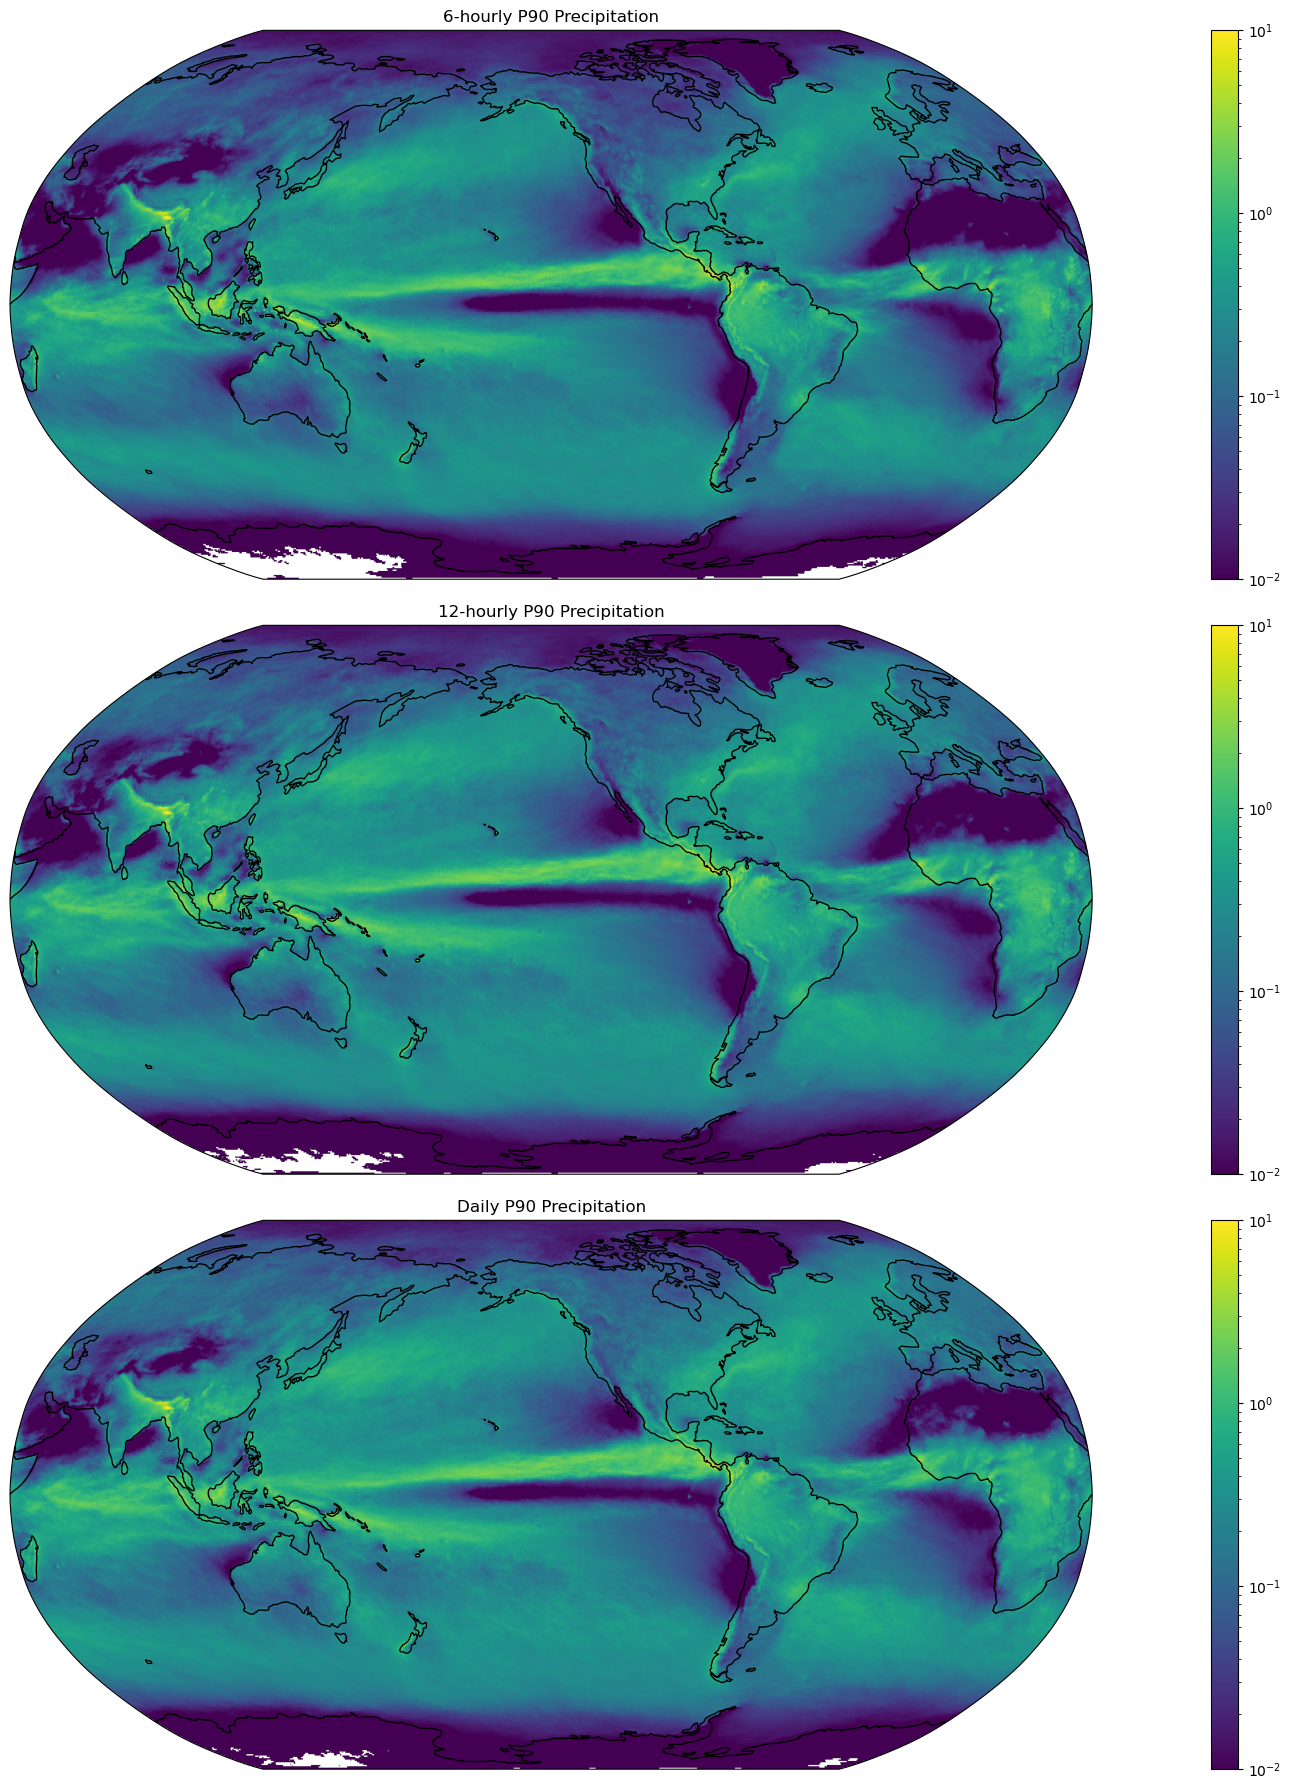

In [31]:
# Create comparison plots for 90th percentile across different time scales
fig, axes = plt.subplots(3, 1, figsize=(24, 18), 
                         subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

# Plot 6-hourly P90
egh_plot(results_6h_computed[90], ax=axes[0], 
         title='6-hourly P90 Precipitation', 
         norm=mpl.colors.LogNorm(vmin=1e-2, vmax=10))

# Plot 12-hourly P90
egh_plot(results_12h_computed[90], ax=axes[1], 
         title='12-hourly P90 Precipitation', 
         norm=mpl.colors.LogNorm(vmin=1e-2, vmax=10))

# Plot daily P90
egh_plot(results_daily_computed[90], ax=axes[2], 
         title='Daily P90 Precipitation', 
         norm=mpl.colors.LogNorm(vmin=1e-2, vmax=10))

plt.tight_layout()
plt.show()

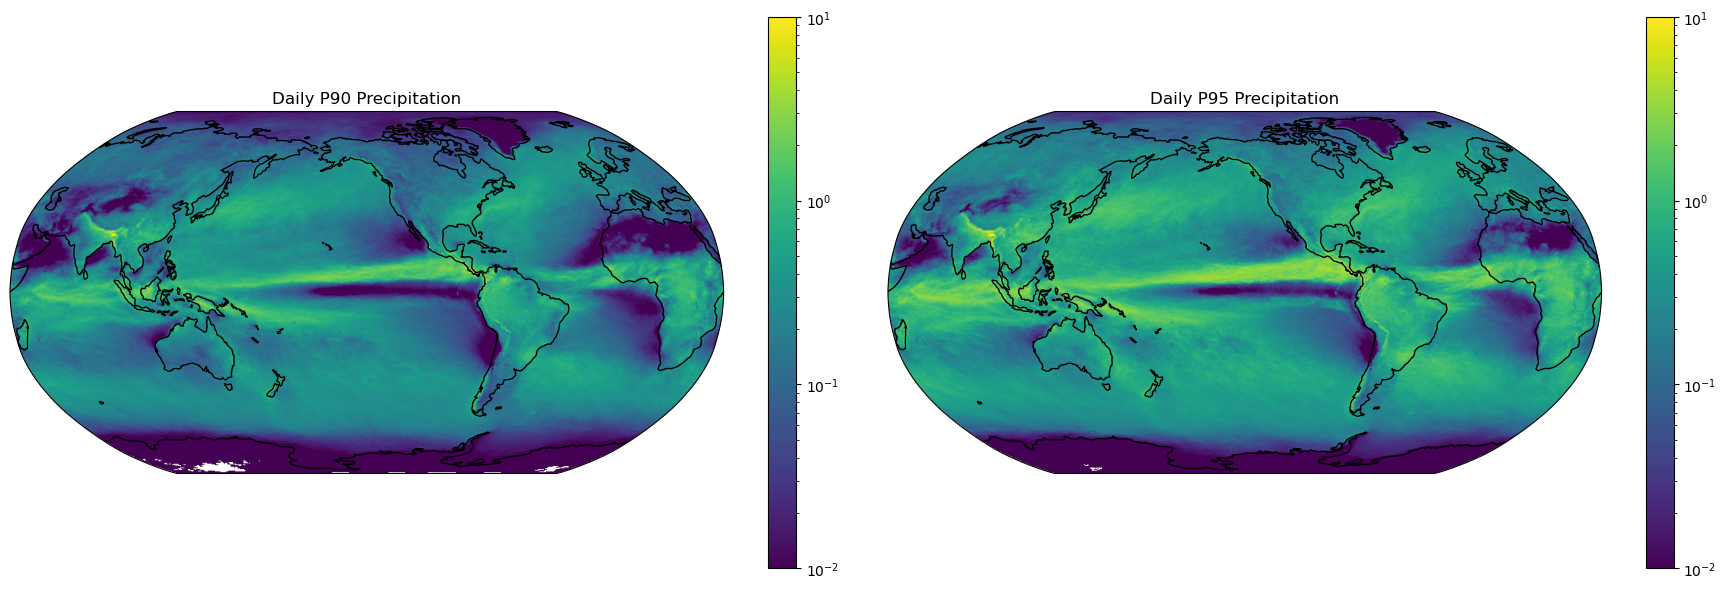

In [29]:
# Compare 90th vs 95th percentile for daily data
fig, axes = plt.subplots(1, 2, figsize=(18, 6), 
                         subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

# Plot daily P90
egh_plot(results_daily_computed[90], ax=axes[0], 
         title='Daily P90 Precipitation', 
         norm=mpl.colors.LogNorm(vmin=1e-2, vmax=10))

# Plot daily P95
egh_plot(results_daily_computed[95], ax=axes[1], 
         title='Daily P95 Precipitation', 
         norm=mpl.colors.LogNorm(vmin=1e-2, vmax=10))

plt.tight_layout()
plt.show()

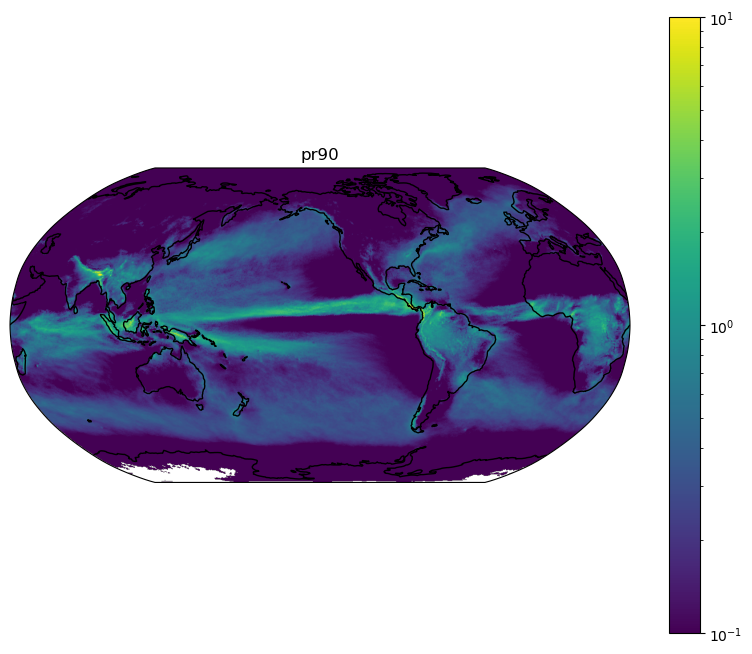

In [30]:
fig, ax0 = plt.subplots(1, 1, figsize=(10, 8), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

egh_plot(pr_p90, ax=ax0, title=f'pr90', norm=mpl.colors.LogNorm(vmin=10e-2, vmax=10))